# Simulation of satellite-detected hailstorms in the Australian tropics

In the Australian tropics, satellites and proxies often see indications of hail or hail-prone conditions, yet the actual occurrance of hail at the surface is uncertain given sparse observations. Here I use WRF to simulate hailstorms where satellite retrievals detected the presence of hail (aloft). The simulations are run using three microphysics schemes.

In [3]:
%cd ~/git/kimberley_hail

/home/561/tr2908/git/kimberley_hail


In [4]:
import json
import os
import sys

sys.path.append('../xarray_parcel/')

import glob

import cartopy.crs as ccrs
import dask
import matplotlib.pyplot as plt
import modules.nth_hail as nh
import modules.wrf_metadata as wm
import numpy as np
import pandas as pd
import seaborn as sns
import xarray
from dask.distributed import Client


In [5]:
client = Client(n_workers=24, threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38143 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:38143/status,
Dashboard: http://127.0.0.1:38143/status,Workers: 24
Total threads: 24,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35941,Workers: 0
Dashboard: http://127.0.0.1:38143/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39395,Total threads: 1
Dashboard: http://127.0.0.1:40333/status,Memory: 5.22 GiB
Nanny: tcp://127.0.0.1:35735,


## Environment

In [6]:
!module list

Currently Loaded Modulefiles:
 1) singularity                                         3) R/4.3.1  
 2) conda/analysis3-25.07(analysis3:esmvaltool:ilamb)   4) pbs      
>

In [7]:
!python --version

Python 3.11.13


## Notes after conversation with Sarah Bang Feb 25

- Check graupel vs hail profiles
- Check melting profiles
- Check sounding against jobs
- Check indices on box plots — are they reversed
- Mean profiles to look at shape of the CAPE

- Terminal velocity and melting parameterisations seems to outweigh environment factors
- Are the storm “resources” being used in grapple or hail production? Competitive processes!! 
- Add S06 to box plots
- More cases
- Compare GPM-assumed size of hail at -20 C to ground-based radar and model results.

- Gucci et al, Rutlitch, Dolan, 2020 JGRA
- Competition between graupel and hail production.
- Rimed density threshold to give graupel
  - Big storm area is more easily detected by satellite


WRF was stopping during runs using the MY2 microphysics scheme. When I asked Jason Milbrandt about this he wrote:

`Regarding MY2, that abort message has burned me many times.  It is a forced abort designed to give that warning message if the input temperature is unreasonable.  What is likely happening is that it is in a strong updraft and the intermediate adiabatic cooling due to ascent (after the dynamics but before the microphysics) results in a temporarily very cold temperature.  Several years ago I was running a squall line case in WRF with several other MP schemes; I put print statements in those other codes and similar temperatures appeared in those schemes also.  Ultimately (by the end of the time step) the saturation adjustment and diabetic heating returns the temperature back to sane values.  In short, it probably is not a problem in MY2 (at least that’s my guess).  The fix would be either to use a smaller time step or just comment out the STOP statement in the code.`

So, I have commented out these lines in WRF's `WRF/WRF/phys/module_mp_milbrandt2mom.F` file:

```
!-----                                                                                                                                                                  
!  if ( T(i,k)<173. .or. T(i,k)>323.) then                            !** DEBUG **                                                                                      
!     print*, '** STOPPING IN MICROPHYSICS: (Part 2, end) **'         !** DEBUG **                                                                                      
!     print*, '** i,k,T [K]: ',i,k,T(i,k)                             !** DEBUG **                                                                                      
!     stop                                                            !** DEBUG **                                                                                      
!  endif                                                              !** DEBUG **                                                                                      
!=====                                                                                  
```

## Settings

In [8]:
detecs_file = 'data/GPM_2014_2024_hail_events_P20_KIMB.nc'              # Bang & Cecil 2019 hail detections.
sims_dir = '/g/data/li18/tr2908/kimberley_hail/WRF_v4.6.0/simulations/' # Directory where simulations are held.
wrf_dir = '/g/data/li18/tr2908/kimberley_hail/WRF_v4.6.0/template/'     # Directory with compiled WRF.
namelist_dir = 'namelists/'                                             # Directory with template namelists.
prob_req = 0.5                                                          # Hail probability required to include event.

## Setup

In [9]:
plt.show()                                                       # Start the plotting engine.
plt.rcParams['font.size'] = 12                                   # Font size for plots.
plt.rcParams['axes.formatter.useoffset'] = False                 # Don't use offsets in plots.
_ = dask.config.set({'array.slicing.split_large_chunks': False}) # Allow for large dask chunks.
results = {}                                                     # Dictionary for reportable results.

## Event selection

Events to simulate are selected from data provided by Sarah Bang, with locations and times of satellite-detected hailstorms. We look for "good" detections in northern Australia with a hail probability over 50%.

In [10]:
hail_detections = xarray.open_dataset(detecs_file).to_pandas()
hail_detections = hail_detections[hail_detections.DCflag == 1] # Select storms not flagged for snow/surface features.
hail_detections = hail_detections[hail_detections.p_hail_BC2019 > prob_req] # Select only probable detections.
hail_detections = hail_detections[hail_detections.year < 2024] # ERA5 catalogue is only updated to Sep 2023 for now.  # noqa: PLR2004
hail_detections = hail_detections[np.logical_not(hail_detections.year == 2023, hail_detections.month > 9)]  # noqa: PLR2004
hail_detections = hail_detections.reset_index(drop=True)
hail_detections['minute'] = np.floor(60 * (hail_detections.hour % 1))
hail_detections['hour'] = np.floor(hail_detections.hour)
print(f'The dataset contains {len(hail_detections)} hail detections.')
results['number_detections'] = len(hail_detections)

The dataset contains 57 hail detections.


We simulate the hour before the event, the hour of the event and the hour after the event, so each event has 3 hours of simulation time. The start time is shifted back 12 hours to give a 12 hour spin-up time. Total simulation time is then 15 hours per event.

In [11]:
hail_detections['event_time'] = (
    hail_detections.year.astype(int).astype(str).str.zfill(2)
    + '-'
    + hail_detections.month.astype(int).astype(str).str.zfill(2)
    + '-'
    + hail_detections.day.astype(int).astype(str).str.zfill(2)
    + ' '
    + hail_detections.hour.astype(int).astype(str).str.zfill(2)
    + ':'
    + hail_detections.minute.astype(int).astype(str)
)
hail_detections['event_time'] = pd.to_datetime(hail_detections.event_time, format='%Y-%m-%d %H:%M')
hail_detections['start_time'] = (hail_detections.event_time - np.timedelta64(13, 'h')).dt.floor('h')
hail_detections['end_time'] = (hail_detections.event_time + np.timedelta64(1, 'h')).dt.ceil('h')
hail_detections['start_time'] = hail_detections.start_time.dt.strftime('%Y-%m-%d_%H:%M:00')
hail_detections['end_time'] = hail_detections.end_time.dt.strftime('%Y-%m-%d_%H:%M:00')

In [12]:
hail_detections

,year,month,day,hour,latitude,longitude,p_hail_BC2019,DCflag,DCscore,minute,event_time,start_time,end_time
0,2014.0,12.0,4.0,11.0,-15.447296,130.743835,0.640928,1.0,0.999,32.0,2014-12-04 11:32:00,2014-12-03_22:00:00,2014-12-04_13:00:00
1,2014.0,12.0,5.0,10.0,-18.051325,139.738251,0.869298,1.0,0.998,41.0,2014-12-05 10:41:00,2014-12-04_21:00:00,2014-12-05_12:00:00
2,2014.0,12.0,6.0,11.0,-15.750792,126.886223,0.612656,1.0,0.999,20.0,2014-12-06 11:20:00,2014-12-05_22:00:00,2014-12-06_13:00:00
3,2014.0,12.0,7.0,10.0,-19.409584,129.686066,0.799357,1.0,0.795,28.0,2014-12-07 10:28:00,2014-12-06_21:00:00,2014-12-07_12:00:00
4,2014.0,12.0,14.0,9.0,-15.357926,125.715347,0.625072,1.0,0.999,1.0,2014-12-14 09:01:00,2014-12-13_20:00:00,2014-12-14_11:00:00
5,2015.0,1.0,21.0,20.0,-15.813498,139.214340,0.560034,1.0,0.999,54.0,2015-01-21 20:54:00,2015-01-21_07:00:00,2015-01-21_22:00:00
6,2015.0,1.0,25.0,7.0,-16.844877,129.381775,0.603321,1.0,0.999,14.0,2015-01-25 07:14:00,2015-01-24_18:00:00,2015-01-25_09:00:00
7,2015.0,2.0,20.0,0.0,-12.479103,121.351273,0.575416,1.0,0.999,15.0,2015-02-20 00:15:00,2015-02-19_11:00:00,2015-02-20_02:00:00
8,2015.0,2.0,21.0,12.0,-17.161983,125.059578,0.859441,1.0,0.999,39.0,2015-02-21 12:39:00,2015-02-20_23:00:00,2015-02-21_14:00:00
9,2015.0,2.0,26.0,11.0,-18.230198,123.119972,0.645392,1.0,0.999,26.0,2015-02-26 11:26:00,2015-02-25_22:00:00,2015-02-26_13:00:00


Here is a map showing the locations of the hail detections we study here as red dots.

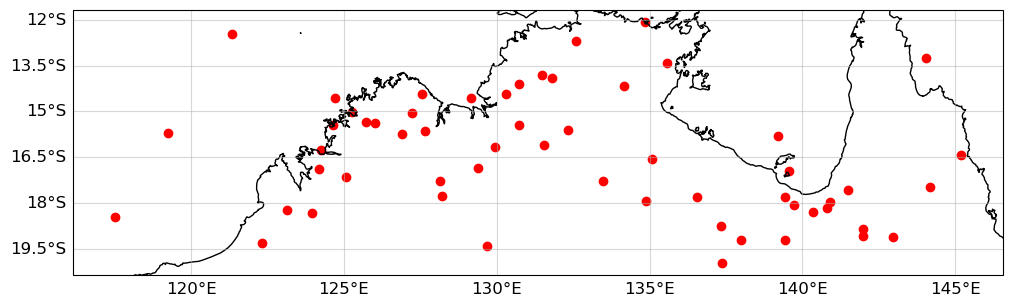

In [13]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,8))
ax.scatter(hail_detections.longitude, hail_detections.latitude, transform=ccrs.PlateCarree(), color='red')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, alpha=0.5)
gl.top_labels = gl.right_labels = False
ax.coastlines()
plt.show()

## Simulation computation

The following code can be run to create a directory for each simulation and set up all the namelist files to use the correct locations and times.

In [14]:
# for _, row in hail_detections.iterrows():
#     nh.set_up_WRF(lat=row.latitude, lon=row.longitude, year=row.year, month=row.month, day=row.day,
#                   hour=row.hour, minute=row.minute, start_time=row.start_time, end_time=row.end_time,
#                   wrf_dir=wrf_dir, sims_dir=sims_dir, namelist_dir=namelist_dir)

To run WPS for each simulation:

```
cd /g/data/li18/tr2908/kimberley_hail/WRF_v4.6.0/simulations/
for i in lat*; do cd $i/WPS; echo `pwd`; qsub ~/git/kimberley_hail/scripts/run_WPS.sh; cd ../../; done
```

Once WPS has run on all, then run WRF:

```
cd /g/data/li18/tr2908/kimberley_hail/WRF_v4.6.0/simulations/
for i in lat*/WRF/*; do cd $i; echo `pwd`; qsub ~/git/kimberley_hail/scripts/run_WRF.sh; cd ../../../; done
```

After WRF has finished, then run two scripts to calculate basic properties for the last three files (leaving out spin up):

```
cd /g/data/li18/tr2908/kimberley_hail/WRF_v4.6.0/simulations/
for i in lat*/WRF/*; do cd $i; echo `pwd`; qsub ~/git/kimberley_hail/scripts/process_WRF_basic.sh; cd ../../../; done
```

Run a script to calculate convective properties:

```
cd /g/data/li18/tr2908/kimberley_hail/WRF_v4.6.0/simulations/
for i in lat*/WRF/*; do cd $i; echo `pwd`; qsub ~/git/kimberley_hail/scripts/process_WRF_conv.sh; cd ../../../; done
```

And finally run a script to interpolate vertical data to pressure levels:

```
cd /g/data/li18/tr2908/kimberley_hail/WRF_v4.6.0/simulations/
for i in lat*/WRF/*; do cd $i; echo `pwd`; qsub ~/git/kimberley_hail/scripts/interpolate_to_hPa_levels.sh; cd ../../../; done
```

To clean out symlinks to reduce inode usage:

```
cd /g/data/li18/tr2908/kimberley_hail/WRF_v4.6.0/simulations/
bash ~/git/kimberley_hail/scripts/clean_runs.sh
```

To remove the "missing_values" attribute that caused xarray warnings from `basic_*.nc files`, I ran:

```
cd /g/data/li18/tr2908/kimberley_hail/WRF_v4.6.0/simulations/
for i in lat*/WRF/*/basic*.nc; do echo $i; ncatted -O -a missing_value,pressure,d,, $i; done
```

## Simulation details

Here are details of the simulation setup, which is simply moved and placed over each hail detection. Three different microphysics schemes are used (NSSL, P3-3M, and MY2).

In [15]:
row = hail_detections.iloc[1,]
dr = nh.sim_directory(lat=row.latitude, lon=row.longitude, year=row.year, month=row.month,
                      day=row.day, hour=row.hour, minute=row.minute, sims_dir=sims_dir)
wm.analyse_wrfinput(glob.glob(f'{dr}/WRF/NSSL/wrfout*')[0])

Sea surface temperature (SST):			0.0 K
Surface skin temperature (TSK):			301.94363 K
Soil temperature at lower boundary (TMN):	299.27527 K
Horizontal grid spacing (DX):			1000.0 m
Horizontal (S-N) grid spacing (DY):		1000.0 m
Horizontal (W-E) domain size:			120 mass points
Horizontal (S-N) domain size:			120 mass points
Vertical domain size:				79 mass points
Maximum geopotential height (model-top):	20546.2 m
Min, mean, max vertical dist. between mass pts:	54.1, 259.7, 353.7 m
Model-top pressure:				5000.0 Pa
Physics schemes:
	Microphysics:				18 (NSSL 2-moment with CCN prediction)
	Radiation (longwave):			4 (RRTMG)
	Radiation (shortwave):			4 (RRTMG)
	Surface layer:				1 (Revised MM5 Monin-Obukhov)
	Land-surface:				4 (Noah-MP)
	PBL:					1 (YSU)
	Cumulus:				0 (No cumulus parameterisation)
Turbulence options:
	Diffusion (diff_opt):			2 (Full diffusion)
	Eddy coefficient (km_opt):		4 (2D (horiz) Smagorinsky)


## Read data

In [16]:
if not os.path.exists('results/spatial_means.nc'):
    dat = nh.open_kimberley_data(hail_detections=hail_detections, sims_dir=sims_dir)
    dat = dat.chunk({'event': 1, 'mp_scheme': 1, 'south_north': -1, 'west_east': -1, 'pressure_level': -1, 'timestep': -1})
    removed_large_hailcast_perc = np.mean(dat.hailcast_diam_max > 200).values
    print(f'Removing {np.round(np.mean(dat.hailcast_diam_max > 200).values * 100, 8)}% of points for hailcast max diam > 200 mm (20 cm).')
    dat = dat.where(dat.hailcast_diam_max <= 200)
    dat['event_includes_hail'] = (dat.hailcast_diam_max.max(['timestep', 'south_north', 'west_east']) > 0).load()
    dat['event_latitude'] = dat.latitude.mean(['timestep', 'south_north', 'west_east']).load()
    dat['event_longitude'] = dat.longitude.mean(['timestep', 'south_north', 'west_east']).load()

    spatial_means = dat.mean(['south_north', 'west_east'], keep_attrs=True).load()

    comp = {'zlib': True, 'complevel': 5}
    encoding = {var: comp for var in spatial_means.data_vars}
    spatial_means.attrs['removed_hailcast_over_200mm_percent'] = removed_large_hailcast_perc
    spatial_means.to_netcdf('results/spatial_means.nc', encoding=encoding)
else:
    spatial_means = xarray.open_dataset('results/spatial_means.nc')

In [17]:
hour_before = slice(-36, -24)
hour_of = slice(-24, -12)
hour_after = slice(-12, None)

## Number of hail vs no-hail simulations

In [52]:
num_simulations = len(spatial_means.event) * len(spatial_means.mp_scheme)
hail_events = np.sum(spatial_means.event_includes_hail).values
nohail_events = np.sum(np.logical_not(spatial_means.event_includes_hail)).values
assert hail_events + nohail_events == num_simulations, 'Error in hail event count'

results['number_mp_schemes'] = len(spatial_means.mp_scheme)
results['hail_cases'] = int(hail_events)
results['nohail_cases'] = int(nohail_events)

print(f'{hail_events}/{num_simulations}\t({np.round(hail_events/num_simulations*100,1)}%) of the simulations contained surface hail.')
print(f'{nohail_events}/{num_simulations}\t({np.round(nohail_events/num_simulations*100,1)}%) of the simulations contained no surface hail.')

139/228	(61.0%) of the simulations contained surface hail.
89/228	(39.0%) of the simulations contained no surface hail.


In [53]:
results

{'number_detections': 57,
 'number_mp_schemes': 4,
 'hail_cases': 139,
 'nohail_cases': 89}

In [ ]:
from importlib import reload

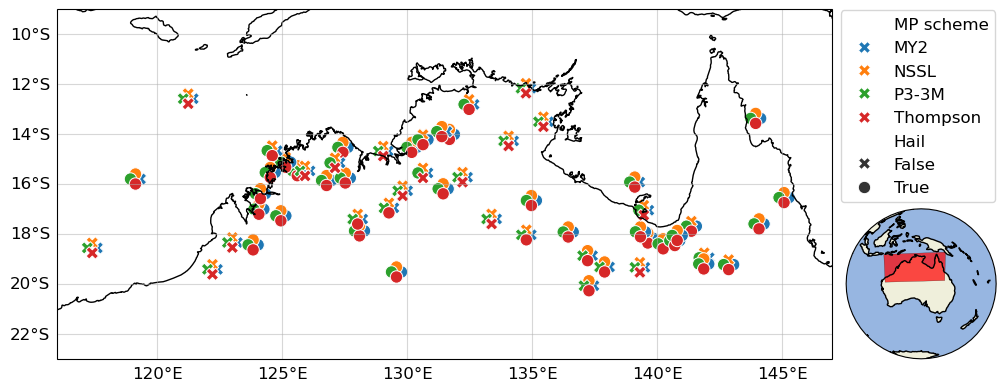

In [ ]:
nh.plot_hail_simulations(dat=spatial_means, ylim=(-23,-9), xlim=(116, 147), figsize=(10,5), file='paper/figures/sims_map.pdf')

## Mean skew-T plots by microphysics scheme for hour of hail detection

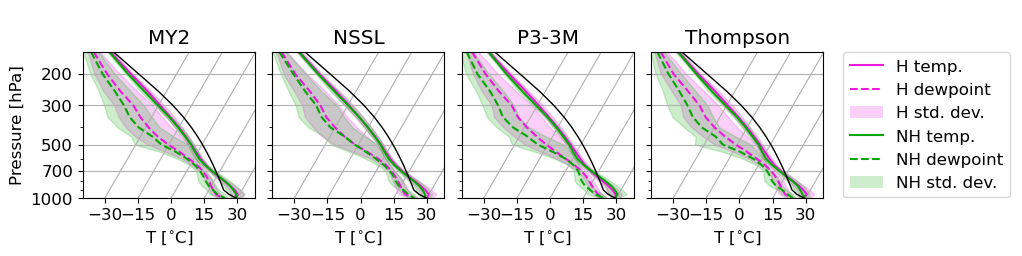

In [ ]:
nh.skew_T_comp(dat=spatial_means, time_slice=hour_of, figsize=(12,3), file='paper/figures/skewT_comp.pdf')

## Mean vertical profiles of hydrometeor mixing ratios for hour of hail detection

In [ ]:
nh.comp_profiles(
    dat=spatial_means,
    factor=1000,
    variables=['qcloud_at_p', 'qrain_at_p', 'qice_at_p', 'qhail_at_p'],
    varnames={
        'qcloud_at_p': 'Cloud [g kg$^{-1}$]',
        'qrain_at_p': 'Rain [g kg$^{-1}$]',
        'qice_at_p': 'Ice [g kg$^{-1}$]',
        'qhail_at_p': 'Hail [g kg$^{-1}$]',
    },
    time_slice=hour_of,
    figsize=(12,11),
    file='paper/figures/hydromets.pdf',
)

## Mean vertical profiles of humidity, wind, and radar reflectivity for hour of hail detection 

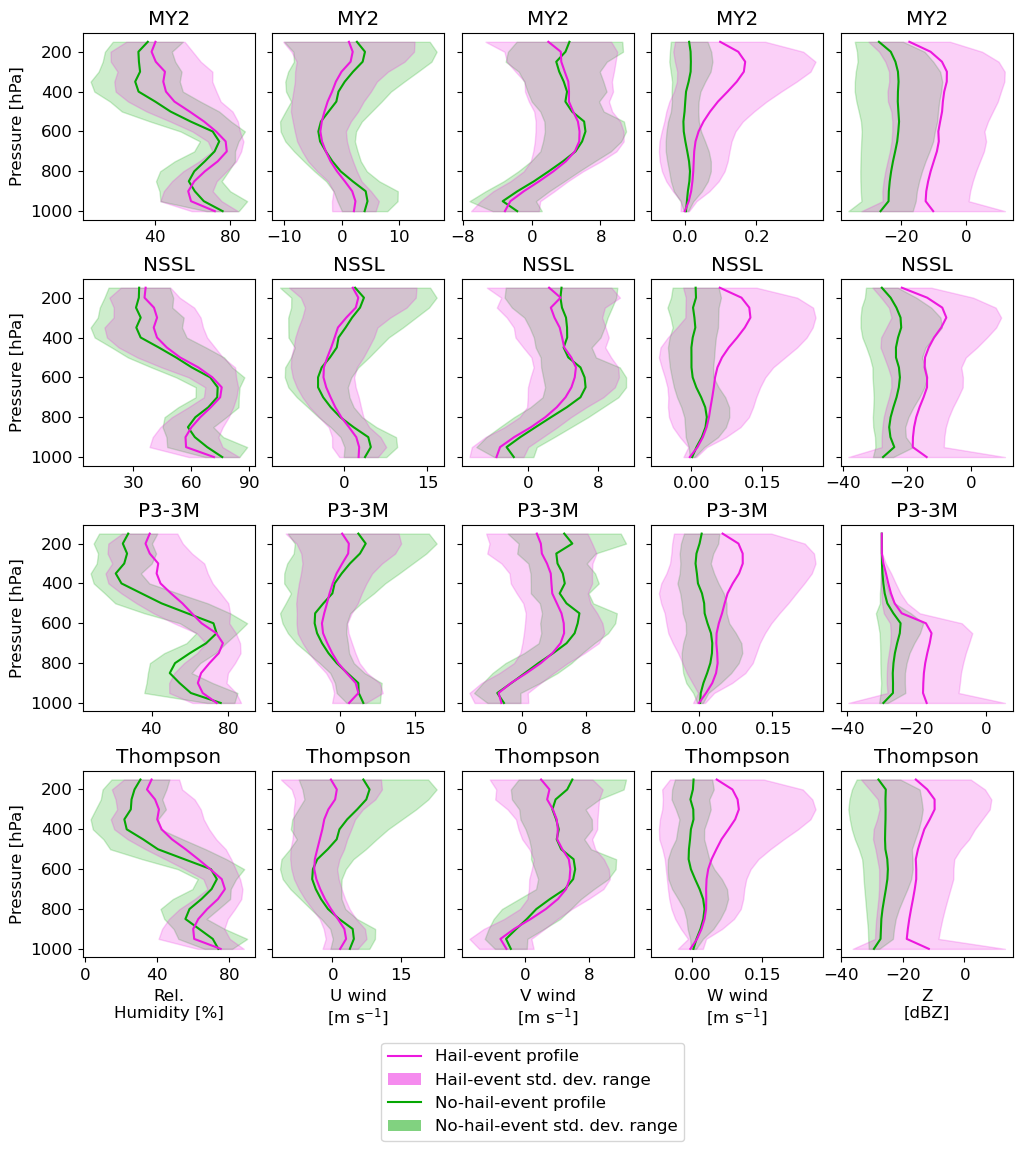

In [46]:
nh.comp_profiles(
    dat=spatial_means,
    variables=['rh_at_p', 'u_at_p', 'v_at_p', 'w_at_p', 'dbz_at_p'],
    varnames={
        'rh_at_p': 'Rel.\nHumidity [%]',
        'u_at_p': 'U wind\n[m s$^{-1}$]',
        'v_at_p': 'V wind\n[m s$^{-1}$]',
        'w_at_p': 'W wind\n[m s$^{-1}$]',
        'dbz_at_p': 'Z\n[dBZ]',
    },
    time_slice=hour_of,
    file='paper/figures/profiles.pdf',
)

The locations of the hail/no hail simulations show no particular spatial pattern.

In [45]:
variables = ['mixed_100_cape', 'mixed_100_cin', 'freezing_level', 'lapse_rate_700_500', 'temp_500']
var_names = ['CAPE [J kg$^{-1}$]', 'CIN [J kg$^{-1}$]', 'FLH [m]', 'MLH [m]', 'LR 700-500 [K km$^{-1}$]', 'T500 [K]']
conv = profs[variables].to_dataframe().reset_index().rename(columns={'event_includes_hail': 'Hail'})
figsize = (14,5)
fig, axs = plt.subplots(ncols=len(variables), figsize=figsize)
for i, v in enumerate(variables):
    sns.boxplot(data=conv, y=v, hue='Hail', ax=axs[i], legend=i==0)
    axs[i].set_xlabel(var_names[i])
    axs[i].set_ylabel('')
plt.tight_layout()

NameError: name 'profs' is not defined

In [ ]:
variables = ['temperature_at_p', 'rh_at_p', 'w_at_p', 'u_at_p', 'v_at_p', 'dbz_at_p']
var_names = ['T [K]', 'RH [%]', 'Vert. wind [m s-1]', 'U wind [m s-1]', 'V wind [m s-1]', 'Z [dBZ]']
conv = profs[variables].mean('timestep').to_dataframe().reset_index().rename(columns={'event_includes_hail': 'Hail'})
figsize = (15,5)
fig, axs = plt.subplots(ncols=len(variables), figsize=figsize)
for i, v in enumerate(variables):
    sns.lineplot(data=conv, y='pressure_level', x=v, hue='Hail', ax=axs[i], legend=i==0, sort=False)
    axs[i].set_xlabel(var_names[i])
    axs[i].set_ylabel('hPa')
    axs[i].invert_yaxis()
plt.tight_layout()

Ideas:
- In [this paper](https://www.sciencedirect.com/science/article/pii/S0169809522001296) HAILCAST was tested in Croatia with various schemes; they also ran at 1 km and said they found false alarms from HAILCAST, which they related to the updraft threshold for when HAILCAST is run. HAILCAST was designed for 3km runs and uses a 10 ms-1 updraft threshold; at 1km they used 18 ms-1 as an updated threshold. 
- In [Johnson MWR 2019](https://doi.org/10.1175/MWR-D-18-0398.1) different microphysics schemes are tested for idealised and real hail cases. The original P3 scheme does not perform so well, which is why the P3-3M scheme (used here) was developed.

In [ ]:
# Profiles of hail by size where microphysics schemes allow it

## Write results for paper

In [54]:
with open('paper/results/results.json', 'w') as json_file:
    json.dump(results, json_file, indent=4)